# Matchup metrics & figures (Stage 6)

Compare the satellite `b_bp` against the BGC-Argo `b_bp` in log space and render
the population + scene figures (`pab.metrics`, `pab.plotting`). This runs on
**synthetic** matchup results offline — no BING/network — so it carries committed
outputs. The metric math is quantity-agnostic, so the same calls serve **Chl** (BING retrieves it from the fitted Aph) and
the BING-vs-NASA comparison.

## 1. Log-space comparison metrics

The core is `log_comparison(sat, insitu)` — median ratio + IQR, Spearman ρ, log bias and RMS/MAD — on any paired arrays.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pab.metrics import compare

rng = np.random.default_rng(7)
n = 40
bbp_argo = 10 ** rng.uniform(-3.3, -2.3, n)         # ~5e-4 .. 5e-3
bbp_bing = bbp_argo * 1.3 * 10 ** rng.normal(0, 0.12, n)   # ~1.3x w/ scatter
stats = compare.log_comparison(bbp_bing, bbp_argo)
for k, v in stats.items():
    print(f"  {k:13s} {v:.4g}")

  n             40
  median_ratio  1.3
  ratio_iqr_lo  1.135
  ratio_iqr_hi  1.565
  spearman      0.964
  log_bias      0.1141
  log_rms       0.1547
  log_mad       0.0773


## 2. A synthetic matchup population

Assemble a frame like `gather_matchups` returns, add season/region strata, and compute the stratified median ratios.

In [2]:
months = rng.integers(1, 13, n)
lat = rng.uniform(-60, 60, n)
df = pd.DataFrame({
    "matchup_id": [f"M{i}" for i in range(n)],
    "bbp_bing": bbp_bing, "bbp_argo": bbp_argo,
    "chla_argo": 10 ** rng.uniform(-1.3, 0.3, n),
    "latitude": lat, "longitude": rng.uniform(-180, 180, n),
    "time": [f"2025-{m:02d}-15T12:00:00" for m in months],
})
df["chl_bing"] = df["chla_argo"] * 1.2 * 10 ** rng.normal(0, 0.15, n)  # BING Chl
df = compare.add_strata(df)
by_region = df.groupby("region").apply(
    lambda g: compare.compare(g, "bbp_bing", "bbp_argo")["median_ratio"])
print("median bbp_sat/bbp_float by region:")
print(by_region.round(2))

median bbp_sat/bbp_float by region:
region
polar         1.39
subtropics    1.14
temperate     1.28
tropics       1.34
dtype: float64


## 3. Population scatter

Satellite-vs-float `b_bp`, log-log, with 1:1 and the median-ratio offset line (`pab.plotting.population`).

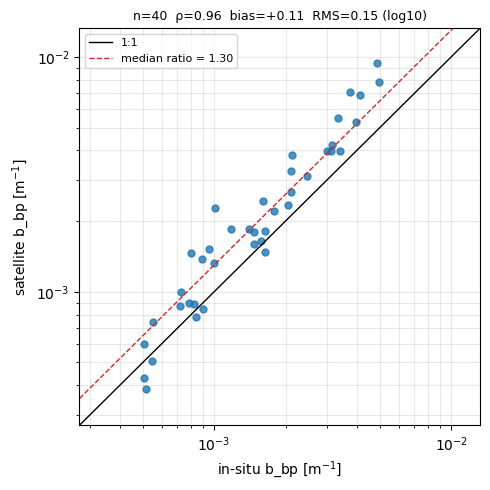

In [3]:
from pab.plotting import population
fig = population.comparison_scatter(df, "bbp_bing", "bbp_argo", label="b_bp")
plt.show()

### Chl too

BING **retrieves** Chl from the fitted `Aph` (the input `Chl` only seeds the shape), so `chl_bing` vs the Argo `chla` is a genuine retrieval-vs-in-situ comparison — same call, different columns.

{'n': 40, 'median_ratio': 1.1091187524053787, 'ratio_iqr_lo': 0.8565780841750256, 'ratio_iqr_hi': 1.3001921051036192, 'spearman': 0.9448405253283303, 'log_bias': 0.02351163100307794, 'log_rms': 0.15587892578340715, 'log_mad': 0.09698778027681468}


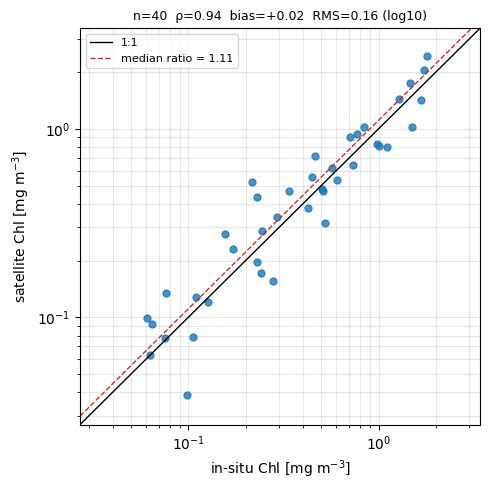

In [4]:
print(compare.compare(df, "chl_bing", "chla_argo"))
fig = population.comparison_scatter(df, "chl_bing", "chla_argo",
                                    label="Chl", unit="mg m$^{-3}$")
plt.show()

## 4. Scene quick-look

A synthetic granule neighbourhood with the float (red star), the analyzed pixels (white circles), and a flagged pixel greyed (`pab.plotting.scene`).

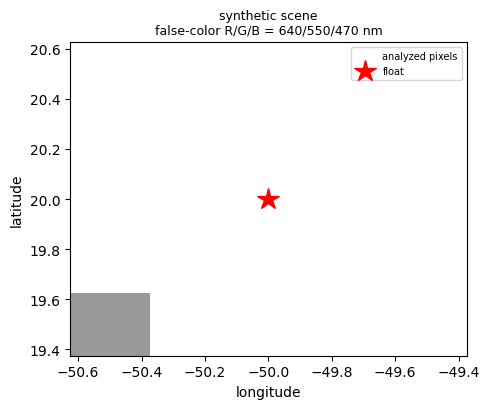

In [5]:
import xarray as xr
from pab.pace import flags
from pab.plotting import scene

nx = ny = 5
latg = np.linspace(19.5, 20.5, nx); long = np.linspace(-50.5, -49.5, ny)
lon2d, lat2d = np.meshgrid(long, latg)
wave = np.linspace(400, 700, 31)
rrs = np.tile(0.01*np.exp(-(wave-400)/150.), (nx, ny, 1))
l2 = np.zeros((nx, ny), dtype=np.int64); l2[0, 0] |= flags.flag_value(["LAND"])
gran = xr.Dataset(
    {"Rrs": (("x","y","wl"), rrs), "Rrs_unc": (("x","y","wl"), rrs*0.05),
     "l2_flags": (("x","y"), l2)},
    coords={"latitude": (("x","y"), lat2d), "longitude": (("x","y"), lon2d),
            "wavelength": ("wl", wave)})
fig = scene.scene_quicklook(gran, 20.0, -50.0,
                            pixels=[{"ix": 2, "iy": 2}, {"ix": 2, "iy": 3}],
                            title="synthetic scene")
plt.show()

## 5. (Optional) real metrics over the populated store

With a DB populated through Stage 5, `compare.gather_matchups(store)` →
`compare.compare(df, "bbp_bing", "bbp_argo")` gives the real population metrics,
`compare.add_oc_chl(df, store)` adds a satellite OC4 Chl, and
`pab.plotting.fit_fig.fit_figure(store, fit_id)` renders a per-matchup fit.

In [6]:
RUN_LIVE = False
if RUN_LIVE:
    from pab.db import Store
    from pab.plotting import fit_fig
    store = Store.open("pab.db")
    df = compare.gather_matchups(store)
    print(compare.compare(df, "bbp_bing", "bbp_argo"))
    # fit_fig.fit_figure(store, df["fit_id"].iloc[0], outfile="fit.png")
